## 3.1.2 vectorize to accelerate

In [10]:
import math
import time
import numpy as np
import torch
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt

In [11]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [12]:
class Timer:
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        self.tik = time.time()

    def stop(self):
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    
    def avg(self):
        return sum(self.times) / len(self.times)
    
    def sum(self):
        return sum(self.times)
    
    def cumsum(self):
        return np.array(self.times).cumsum().tolist()
    

In [13]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]

f'{timer.stop():.5f} sec'


'0.03457 sec'

In [14]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00020 sec'

---
## 3.1.3 Normal Distribution

In [15]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

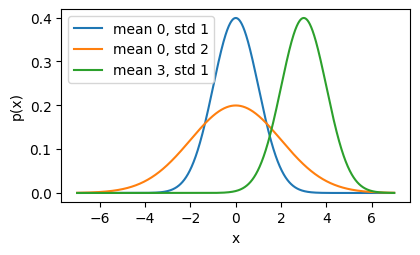

In [21]:
x = np.arange(-7, 7, 0.01)

params = [(0, 1), (0, 2), (3, 1)]

plt.figure(figsize = (4.5, 2.5))
for mu, sigma in params:
    plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()